In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [ ]:
np.random.seed(42)
n = 30

outlook   = np.random.choice(['Sunny','Overcast','Rain'], n,
                              p=[0.4, 0.35, 0.25])
wind      = np.random.choice(['Weak','Strong'], n, p=[0.6, 0.4])
temp_c    = np.where(outlook=='Sunny',
                     np.random.normal(32, 4, n),
                     np.where(outlook=='Overcast',
                              np.random.normal(24, 3, n),
                              np.random.normal(18, 3, n)))
humid_pct = np.where(outlook=='Sunny',
                     np.random.normal(75, 8, n),
                     np.where(outlook=='Overcast',
                              np.random.normal(60, 6, n),
                              np.random.normal(85, 7, n)))
# Word count in post-match notes (low = brief/lazy, high = enthusiastic)
word_cnt  = np.random.randint(5, 150, n)

# Binary flags
has_partner   = np.random.choice([0,1], n, p=[0.35, 0.65])
good_equip    = np.random.choice([0,1], n, p=[0.4,  0.6])
recent_win    = np.random.choice([0,1], n, p=[0.5,  0.5])
weekend_game  = np.random.choice([0,1], n, p=[0.45, 0.55])

# Target: YES if conditions are broadly favourable
play_score = (
    (temp_c < 30).astype(int) +
    (humid_pct < 70).astype(int) +
    (wind == 'Weak').astype(int) +
    (outlook != 'Rain').astype(int) +
    has_partner + recent_win + weekend_game
)
play_tennis = np.where(play_score >= 4, 'Yes', 'No')

df = pd.DataFrame({
    'Outlook':        outlook,
    'Wind':           wind,
    'Temperature_C':  temp_c.round(1),
    'Humidity_pct':   humid_pct.round(1),
    'Notes_WordCount':word_cnt,
    'HasPartner':     has_partner,
    'GoodEquipment':  good_equip,
    'RecentWin':      recent_win,
    'WeekendGame':    weekend_game,
    'PlayTennis':     play_tennis
})

le = LabelEncoder()
y = le.fit_transform(df['PlayTennis'])   # No=0, Yes=1
target_names = le.classes_

print("=" * 62)
print("  PLAY TENNIS+ — DATASET (30 rows)")
print("=" * 62)
print(df.to_string(index=False))
print(f"\n  Class distribution: {dict(df['PlayTennis'].value_counts())}")


  PLAY TENNIS+ — DATASET (30 rows)
 Outlook   Wind  Temperature_C  Humidity_pct  Notes_WordCount  HasPartner  GoodEquipment  RecentWin  WeekendGame PlayTennis
   Sunny Strong           26.1          67.6               90           1              1          0            0        Yes
    Rain   Weak           19.2          87.7               53           0              0          0            1         No
Overcast   Weak           24.3          64.9               74           0              1          1            1        Yes
Overcast Strong           23.1          71.4               19           0              1          0            0         No
   Sunny Strong           33.4          81.5               58           1              0          1            0         No
   Sunny Strong           24.9          65.2              105           1              1          0            0        Yes
   Sunny   Weak           33.3          76.8               12           0              1         

In [ ]:
def plot_cm(cm, title, cmap, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=target_names, yticklabels=target_names,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')


  1. GAUSSIAN NB — continuous features
  Features: Temperature_C, Humidity_pct

  Per-class Gaussian parameters (μ ± σ):
  No: Temp = 29.0°C ± 7.5  Hum = 79.6% ± 6.0
  Yes: Temp = 26.3°C ± 5.4  Hum = 67.2% ± 10.1

  Accuracy: 0.8000
              precision    recall  f1-score   support

          No       0.69      0.82      0.75        11
         Yes       0.88      0.79      0.83        19

    accuracy                           0.80        30
   macro avg       0.79      0.80      0.79        30
weighted avg       0.81      0.80      0.80        30



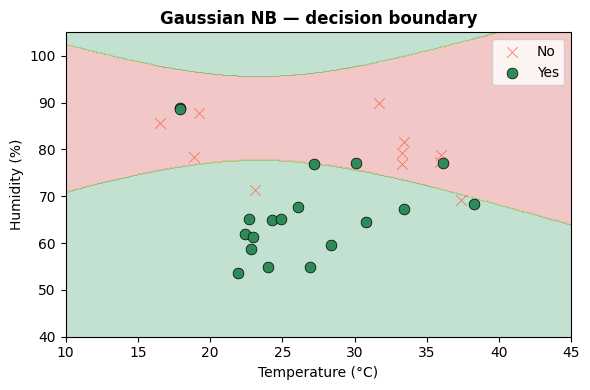

  [Plot saved: gaussian_nb_boundary.png]


In [ ]:
print("\n" + "=" * 62)
print("  1. GAUSSIAN NB — continuous features")
print("  Features: Temperature_C, Humidity_pct")
print("=" * 62)

X_gauss = df[['Temperature_C', 'Humidity_pct']].values
gnb = GaussianNB()
gnb.fit(X_gauss, y)
y_gnb = gnb.predict(X_gauss)

print("\n  Per-class Gaussian parameters (μ ± σ):")
for i, cls in enumerate(target_names):
    mu  = gnb.theta_[i]
    sig = np.sqrt(gnb.var_[i])
    print(f"  {cls}: Temp = {mu[0]:.1f}°C ± {sig[0]:.1f}  "
          f"Hum = {mu[1]:.1f}% ± {sig[1]:.1f}")

print(f"\n  Accuracy: {accuracy_score(y, y_gnb):.4f}")
print(classification_report(y, y_gnb, target_names=target_names))

# Decision boundary plot
fig_g, ax_g = plt.subplots(figsize=(6, 4))
xx, yy = np.meshgrid(np.linspace(10, 45, 300), np.linspace(40, 105, 300))
Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax_g.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
for cls, col, mrk in zip([0,1], ['tomato','seagreen'], ['x','o']):
    mask = y == cls
    ax_g.scatter(X_gauss[mask,0], X_gauss[mask,1],
                 c=col, marker=mrk, s=60, label=target_names[cls], edgecolors='k', lw=0.5)
ax_g.set_xlabel('Temperature (°C)'); ax_g.set_ylabel('Humidity (%)')
ax_g.set_title('Gaussian NB — decision boundary', fontweight='bold')
ax_g.legend()
plt.tight_layout()
plt.savefig('gaussian_nb_boundary.png', dpi=150)
plt.show()
print("  [Plot saved: gaussian_nb_boundary.png]")


  2. MULTINOMIAL NB — count feature
  Feature: Notes_WordCount (word count of post-match notes)

  Log P(word count | class) weights:
  No: log-prob of Notes_WordCount = 0.0000
  Yes: log-prob of Notes_WordCount = 0.0000
  Avg Notes_WordCount when No: 79.9 words
  Avg Notes_WordCount when Yes: 77.4 words

  Accuracy: 0.6333
              precision    recall  f1-score   support

          No       0.00      0.00      0.00        11
         Yes       0.63      1.00      0.78        19

    accuracy                           0.63        30
   macro avg       0.32      0.50      0.39        30
weighted avg       0.40      0.63      0.49        30



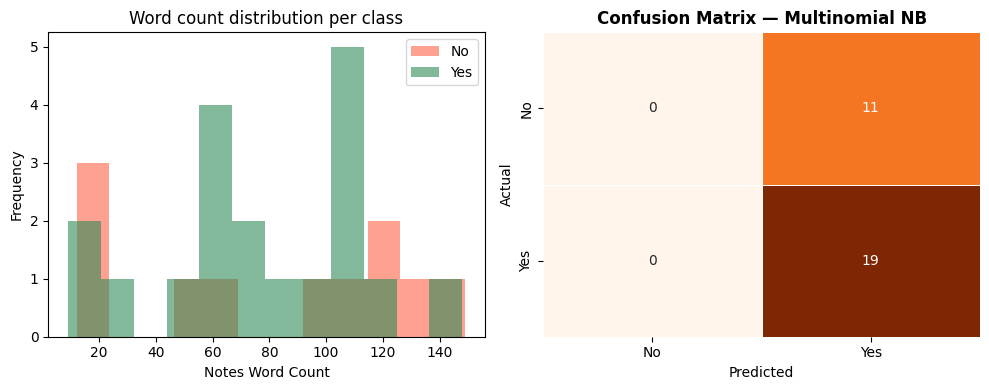

  [Plot saved: multinomial_nb_plot.png]


In [ ]:
print("\n" + "=" * 62)
print("  2. MULTINOMIAL NB — count feature")
print("  Feature: Notes_WordCount (word count of post-match notes)")
print("=" * 62)

X_multi = df[['Notes_WordCount']].values
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_multi, y)
y_mnb = mnb.predict(X_multi)

print("\n  Log P(word count | class) weights:")
for i, cls in enumerate(target_names):
    print(f"  {cls}: log-prob of Notes_WordCount = "
          f"{mnb.feature_log_prob_[i][0]:.4f}")

# Average word count per class
for cls in target_names:
    avg = df.loc[df['PlayTennis']==cls, 'Notes_WordCount'].mean()
    print(f"  Avg Notes_WordCount when {cls}: {avg:.1f} words")

print(f"\n  Accuracy: {accuracy_score(y, y_mnb):.4f}")
print(classification_report(y, y_mnb, target_names=target_names))

# Distribution plot
fig_m, axes_m = plt.subplots(1, 2, figsize=(10, 4))
for cls, col in zip(target_names, ['tomato','seagreen']):
    axes_m[0].hist(df.loc[df['PlayTennis']==cls, 'Notes_WordCount'],
                   bins=12, alpha=0.6, color=col, label=cls)
axes_m[0].set_xlabel('Notes Word Count'); axes_m[0].set_ylabel('Frequency')
axes_m[0].set_title('Word count distribution per class')
axes_m[0].legend()

cm_m = confusion_matrix(y, y_mnb)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Oranges', ax=axes_m[1],
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, cbar=False)
axes_m[1].set_title('Confusion Matrix — Multinomial NB', fontweight='bold')
axes_m[1].set_xlabel('Predicted'); axes_m[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('multinomial_nb_plot.png', dpi=150)
plt.show()
print("  [Plot saved: multinomial_nb_plot.png]")


  3. BERNOULLI NB — binary features
  Features: HasPartner, GoodEquipment, RecentWin, WeekendGame

  P(feature=1 | class) — learned probabilities:
     HasPartner  GoodEquipment  RecentWin  WeekendGame
No        0.308          0.692      0.462        0.385
Yes       0.571          0.714      0.524        0.762

  Accuracy: 0.7000
              precision    recall  f1-score   support

          No       0.67      0.36      0.47        11
         Yes       0.71      0.89      0.79        19

    accuracy                           0.70        30
   macro avg       0.69      0.63      0.63        30
weighted avg       0.69      0.70      0.67        30



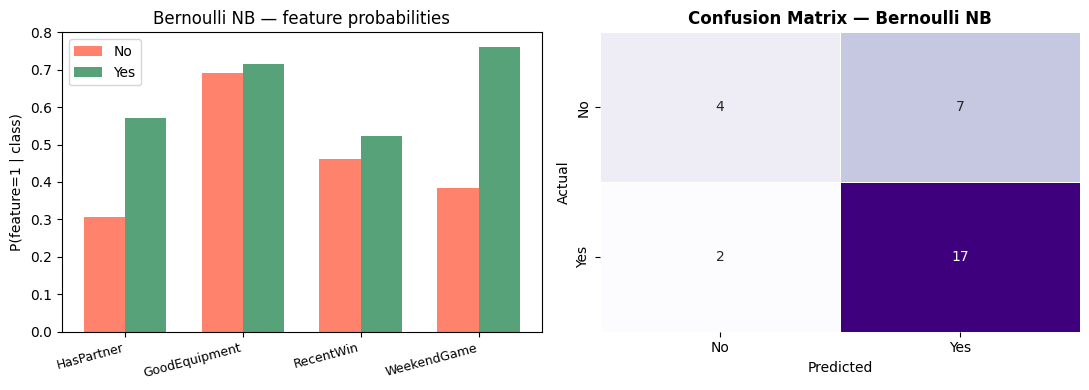

  [Plot saved: bernoulli_nb_plot.png]


In [ ]:
print("\n" + "=" * 62)
print("  3. BERNOULLI NB — binary features")
print("  Features: HasPartner, GoodEquipment, RecentWin, WeekendGame")
print("=" * 62)

bin_feats = ['HasPartner', 'GoodEquipment', 'RecentWin', 'WeekendGame']
X_bern = df[bin_feats].values.astype(int)
bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_bern, y)
y_bnb = bnb.predict(X_bern)

print("\n  P(feature=1 | class) — learned probabilities:")
prob_table = pd.DataFrame(
    np.exp(bnb.feature_log_prob_),
    columns=bin_feats, index=target_names
).round(3)
print(prob_table.to_string())

print(f"\n  Accuracy: {accuracy_score(y, y_bnb):.4f}")
print(classification_report(y, y_bnb, target_names=target_names))

fig_b, axes_b = plt.subplots(1, 2, figsize=(11, 4))
# Feature probability bar chart
x_pos = np.arange(len(bin_feats))
w = 0.35
for i, (cls, col) in enumerate(zip(target_names, ['tomato','seagreen'])):
    axes_b[0].bar(x_pos + i*w, np.exp(bnb.feature_log_prob_[i]),
                  width=w, color=col, alpha=0.8, label=cls)
axes_b[0].set_xticks(x_pos + w/2)
axes_b[0].set_xticklabels(bin_feats, rotation=15, ha='right', fontsize=9)
axes_b[0].set_ylabel('P(feature=1 | class)')
axes_b[0].set_title('Bernoulli NB — feature probabilities')
axes_b[0].legend()

cm_b = confusion_matrix(y, y_bnb)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Purples', ax=axes_b[1],
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, cbar=False)
axes_b[1].set_title('Confusion Matrix — Bernoulli NB', fontweight='bold')
axes_b[1].set_xlabel('Predicted'); axes_b[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('bernoulli_nb_plot.png', dpi=150)
plt.show()
print("  [Plot saved: bernoulli_nb_plot.png]")


  4. CONFUSION MATRIX COMPARISON (all 3 variants)


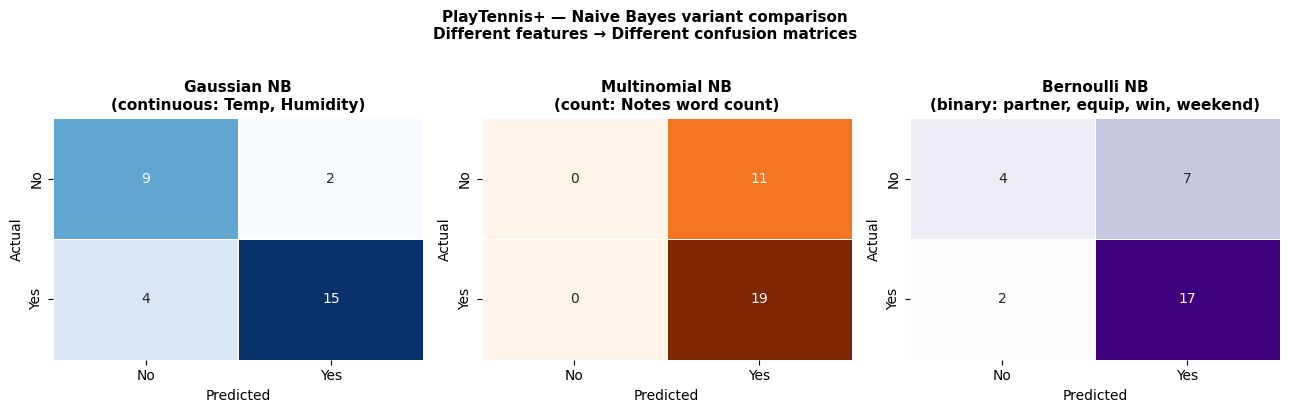

  [Plot saved: nb_comparison_all3.png]


In [ ]:
print("\n" + "=" * 62)
print("  4. CONFUSION MATRIX COMPARISON (all 3 variants)")
print("=" * 62)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, cm_arr, title, cmap in zip(
        axes,
        [confusion_matrix(y, y_gnb),
         confusion_matrix(y, y_mnb),
         confusion_matrix(y, y_bnb)],
        ['Gaussian NB\n(continuous: Temp, Humidity)',
         'Multinomial NB\n(count: Notes word count)',
         'Bernoulli NB\n(binary: partner, equip, win, weekend)'],
        ['Blues', 'Oranges', 'Purples']):
    plot_cm(cm_arr, title, cmap, ax)

fig.suptitle('PlayTennis+ — Naive Bayes variant comparison\n'
             'Different features → Different confusion matrices',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nb_comparison_all3.png', dpi=150, bbox_inches='tight')
plt.show()
print("  [Plot saved: nb_comparison_all3.png]")

In [ ]:
print("\n" + "=" * 62)
print("  5. ACCURACY SUMMARY")
print("=" * 62)

summary = pd.DataFrame({
    'Variant':      ['Gaussian NB', 'Multinomial NB', 'Bernoulli NB'],
    'Features used':['Temperature_C, Humidity_pct',
                     'Notes_WordCount',
                     'HasPartner, GoodEquip, RecentWin, WeekendGame'],
    'Feature type': ['Continuous (real numbers)',
                     'Counts (non-negative integers)',
                     'Binary (0/1)'],
    'Accuracy':     [f"{accuracy_score(y, y_gnb):.4f}",
                     f"{accuracy_score(y, y_mnb):.4f}",
                     f"{accuracy_score(y, y_bnb):.4f}"]
})
print(summary.to_string(index=False))


  5. ACCURACY SUMMARY
       Variant                                 Features used                   Feature type Accuracy
   Gaussian NB                   Temperature_C, Humidity_pct      Continuous (real numbers)   0.8000
Multinomial NB                               Notes_WordCount Counts (non-negative integers)   0.6333
  Bernoulli NB HasPartner, GoodEquip, RecentWin, WeekendGame                   Binary (0/1)   0.7000



  SECTION 7 – SPAM DETECTION (Email Text)

  Dataset: 50 emails (25 spam, 25 ham)

  [7a] Multinomial NB with CountVectorizer (Bag-of-Words)
  Accuracy: 1.0000
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         8
        spam       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

  Top 10 spam words (P(word|spam)):
    free           : 0.0298
    money          : 0.0170
    guaranteed     : 0.0170
    fast           : 0.0170
    claim          : 0.0170
    weight         : 0.0128
    won            : 0.0128
    pills          : 0.0128
    buy            : 0.0128
    offer          : 0.0128

  [7b] Bernoulli NB with Binary CountVectorizer
  Accuracy: 1.0000
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         8
        spam       

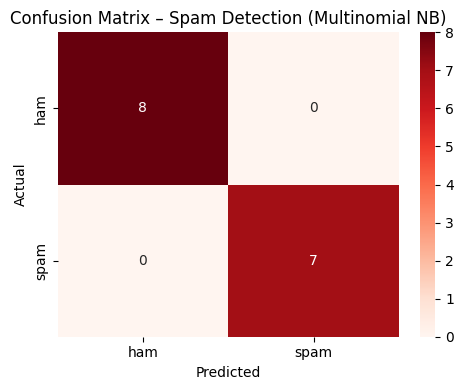

In [ ]:
print("\n" + "=" * 60)
print("  SECTION 7 – SPAM DETECTION (Email Text)")
print("=" * 60)

# Synthetic spam/ham dataset (50 examples)
spam_emails = [
    "Win a free iPhone now click here", "Congratulations you won a lottery prize",
    "Earn money fast working from home", "Free Viagra buy now limited offer",
    "You are selected for cash prize claim it", "Make money online fast guaranteed",
    "Buy cheap pills online discount offer", "You have won a million dollars claim now",
    "Hot singles near you click here free", "Investment opportunity guaranteed returns",
    "Free gift card for you limited time", "Lose weight fast guaranteed results",
    "Double your income working online", "Click here to claim your prize",
    "Exclusive deal buy now free shipping", "Meet singles in your area free signup",
    "Urgent response needed wire transfer", "Get rich quick online scheme",
    "Free casino bonus claim your money", "Win big tonight play now free",
    "Special offer act now limited seats", "Miracle weight loss pills free trial",
    "Earn dollars from home no experience", "Claim your reward click the link below",
    "Your account has been selected prize"
]
ham_emails = [
    "Meeting scheduled for tomorrow morning at 9am", "Please review the attached report",
    "Can we reschedule the project call", "Team lunch is confirmed for Friday",
    "Your invoice is ready for download", "Thank you for your application",
    "The server maintenance is complete", "Please find the agenda for the meeting",
    "Happy birthday hope you have a great day", "Library books due back next week",
    "Flight itinerary confirmation attached", "Your subscription has been renewed",
    "Python tutorial on machine learning algorithms", "Data science conference registration open",
    "Weekly team standup at 10am Monday", "Performance review scheduled next week",
    "Budget report for Q3 is attached", "Code review comments added to your PR",
    "Grocery delivery arriving between 2 and 4pm", "Doctor appointment reminder tomorrow",
    "Newsletter from machine learning digest", "Your package has been shipped",
    "Course assignment deadline extended", "Please update your contact information",
    "Network outage resolved all systems normal"
]

emails = spam_emails + ham_emails
labels = ['spam'] * len(spam_emails) + ['ham'] * len(ham_emails)

df_spam = pd.DataFrame({'email': emails, 'label': labels})
print(f"\n  Dataset: {len(df_spam)} emails ({labels.count('spam')} spam, {labels.count('ham')} ham)")

# Encode labels
le_spam = LabelEncoder()
y_spam = le_spam.fit_transform(df_spam['label'])

# ----- 7a. Multinomial NB (Bag-of-Words) -----
print("\n  [7a] Multinomial NB with CountVectorizer (Bag-of-Words)")
cv = CountVectorizer(stop_words='english', lowercase=True)
X_cv = cv.fit_transform(df_spam['email']).toarray()

X_tr, X_te, y_tr, y_te = train_test_split(X_cv, y_spam, test_size=0.3, random_state=42)
mnb_spam = MultinomialNB(alpha=1.0)
mnb_spam.fit(X_tr, y_tr)
y_pred_spam_mnb = mnb_spam.predict(X_te)

print(f"  Accuracy: {accuracy_score(y_te, y_pred_spam_mnb):.4f}")
print(classification_report(y_te, y_pred_spam_mnb, target_names=le_spam.classes_))

# Top spam words
spam_idx = list(le_spam.classes_).index('spam')
top_spam_idx = np.argsort(mnb_spam.feature_log_prob_[spam_idx])[-10:][::-1]
top_spam_words = [(cv.get_feature_names_out()[i],
                   round(np.exp(mnb_spam.feature_log_prob_[spam_idx][i]), 4))
                  for i in top_spam_idx]
print("  Top 10 spam words (P(word|spam)):")
for word, prob in top_spam_words:
    print(f"    {word:15s}: {prob:.4f}")

# ----- 7b. Bernoulli NB (Binary Presence/Absence) -----
print("\n  [7b] Bernoulli NB with Binary CountVectorizer")
cv_bin = CountVectorizer(stop_words='english', binary=True)
X_bin = cv_bin.fit_transform(df_spam['email']).toarray()

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_bin, y_spam, test_size=0.3, random_state=42)
bnb_spam = BernoulliNB(alpha=1.0)
bnb_spam.fit(X_tr2, y_tr2)
y_pred_spam_bnb = bnb_spam.predict(X_te2)

print(f"  Accuracy: {accuracy_score(y_te2, y_pred_spam_bnb):.4f}")
print(classification_report(y_te2, y_pred_spam_bnb, target_names=le_spam.classes_))

# ----- 7c. Custom spam detector (predict new emails) -----
print("\n  [7c] Predict custom emails")
new_emails = [
    "Congratulations you won a free prize click here to claim",
    "Hi team the meeting is rescheduled to 3pm tomorrow",
    "Limited offer buy now and get free shipping guaranteed",
    "Please review the attached quarterly report before Friday",
]
X_new = cv.transform(new_emails).toarray()
preds = mnb_spam.predict(X_new)
probs = mnb_spam.predict_proba(X_new)

for email, pred, prob in zip(new_emails, preds, probs):
    label = le_spam.inverse_transform([pred])[0]
    print(f"\n  Email : {email[:55]}...")
    print(f"  Label : {label.upper()}")
    for cls, p in zip(le_spam.classes_, prob):
        print(f"    P({cls}) = {p:.4f}")

# Confusion matrix – spam
cm_spam = confusion_matrix(y_te, y_pred_spam_mnb)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_spam, annot=True, fmt='d', cmap='Reds',
            xticklabels=le_spam.classes_, yticklabels=le_spam.classes_, ax=ax)
ax.set_title('Confusion Matrix – Spam Detection (Multinomial NB)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_spam.png', dpi=150)
plt.show()
